<a href="https://colab.research.google.com/github/anjicx/Cormbobidity-Network-Analysis/blob/main/SNA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Korišćenjem mreža kormobiditeta se mogu lakše uočiti obrasci povezanosti između bolesti u odnosu na pojedinčno posmatranje bolesti. Predmet ovog rada je opis strukture mreže komorbiditeta između različitih dijagnoza na osnovu javno dostupnih matrica asocijacija. Cilj je da se korišćenjem mrežnog pristupa ispita struktura povezanosti između različitih dijagnoza, otkriju centralne dijagnoze i izdvoje zajednice međusobno povezanih dijagnoza. Odgovori na ova istraživačka pitanja mogu biti značajni doktorima i ostalom kvalifikovanom osoblju koje bi na osnovu toga moglo doneti detaljnije medicinske zaključke.

In [11]:
#install
!pip -q install statsmodels pyvis igraph

#imports
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pyvis.network import Network
from IPython.display import display, HTML

# **Metodologija**

Matrice asocijacija su matrice log odds vrednosti logističke regresije i p vrednosti njihove statističke značajnosti, dobijenih iz preko million podataka US veterana. Primenom metoda analize mreža, dijagnoze se predstavljaju kao čvorovi, dok statistički značajne i dovoljno jake asocijacije između njih predstavljaju grane. Na ovaj način istražuje se organizacija mreže, značaj pojedinačnih dijagnoza u njenoj strukturi i postojanje grupa međusobno povezanih oboljenja.

# a)	Dostupni podaci

Nakon filtracije koju su istraživači uradili originalni set podataka je sadržao podatke od oko milion (977 183) američkih veterana. Budući da su medicinski setovi podataka setovi sa visoko osetljivim podacima, za analizu su kreirane i stavljene na raspolaganje matrice podataka koje se odnose na logističku regresiju i na p-vrednosti značaja vrednosti dobijenih logističkom regresijom.
Elementi matrice logističke regresije su vrednosti β1 dobijene logističkom regresijom. Model je dat izrazom:

Log(odds)= β1 xj+ β0, gde je:

Xj - indikator prisustva dijagnoze j,

x=0 nema dijagnoze j -> log(odds0) = β0

x=1 prisutna dijagnoza j -> log(odds1) = β1 + β0

ODUZIMANJEM DOBIJAMO -> β1=log(odd1 /odd0)=log(odds ratio)

Elementi matrice logističke regresije predstavljaju log OR (promena log odds-a), odnosno log odds povećanje za pojavu dijagnoze i kada je dijagnoza j već prisutna. Element matrice Aij je samim tim: Aij=β1=log(odds ratio).
Elementi matrice p-vrednosti su dobijeni korišćenjem Wald testa za svaku β1 dobijenu vrednost sa nultom hipotezom da je β1 =0.


In [12]:
# load data from git
if not Path("comorbidityNetworks").exists():
    !git clone https://github.com/aaronab/comorbidity_networks.git
odds = pd.read_csv("comorbidity_networks/comorbidity_odds_matrix.csv", index_col=0)
pval = pd.read_csv("comorbidity_networks/comorbidity_pmat_matrix.csv", index_col=0)

fatal: destination path 'comorbidity_networks' already exists and is not an empty directory.


# b)	Statističko modelovanje

Na osnovu matrice β1 (log odds ratio) vrednosti je kreirana korigovana matrica statistički značajnih ivica dobijenih nakon FDR (false discovery rate) testa. Ovaj test se koristi da smanji broj lažno pozitivnih veza, dobijenih zbog velikog broja sprovedenih Wald testova.

Za potrebe kasnijeg tumačenja je zatim izvršeno eksponovanje β1 .

Nakon eksponovanja, elementi matrice predstavljalju odds ratio pojave dijagnoze i ako je dijagnoza j već prisutna.
Zatim su filtrirane ivice sa ciljem da se izdvoje samo statistički značajne (p<0.05 i OR>1.5).

Budući da je u originalnoj matrici Aij uticaj dijagnoze j na i (j->i), a NetworkX očekuje Aij da je i koje predviđa j (i->j) dodatno je i transponovana matrica.

**ZAŠTO TRANSPONOVANJE?**

Budući da je u originalnoj matrici Aij uticaj dijagnoze j na i (j->i), a NetworkX očekuje Aij da je i koje predviđa j (i->j) dodatno je i transponovana matrica.

In [14]:
# fdr correction
import numpy as np #for work with matrix
from statsmodels.stats.multitest import fdrcorrection #for fdr test
import pandas as pd

P = pval.copy()
n = P.shape[0]
mask = ~np.eye(n, dtype=bool)
pvals = P.values[mask]
_, qvals = fdrcorrection(pvals)

Q = np.zeros(P.shape, dtype=float)
Q[mask] = qvals
qmat = pd.DataFrame(Q, index=P.index, columns=P.columns)

# odds ratio and adjacency matrix
OR = np.exp(odds)
min_or = 1.5
alpha = 0.05

mask_edges = (qmat < alpha) & (OR > min_or)
A_or = OR.where(mask_edges, other=0)
A_adj = A_or.T

# c)	Mrežna analiza

Od matrice OR statistički značajnih ivica kormobiditeta je kreiran usmereni graf kormobiditeta. Čvorovi predstavljaju medicinske i psihičke dijagnoze, a ivice nam označavaju koliko je veći odds da se u prisustvu i-te dijagnoze desi j u odnosu na to u odsustvu i. Na osnovu naziva čvorova su podeljeni čvorovi u one koji su vezani za psihičke i fizičke bolesti, a zatim su im dodeljeni medicinski kraći nazivi. Nakon kreiranja grafa, ispituje se broj ivica i čvorova kod kreiranog grafa i podgrafova.


In [15]:
# build graph
G = nx.from_pandas_adjacency(A_adj, create_using=nx.DiGraph)
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
for edge in list(G.edges(data=True))[:10]:
    print(edge)

nodes: 95 edges: 1327
('AHRQ_AbdominalHernia_DT', 'AHRQ_BiliaryTractDs_DT', {'weight': 1.7510259052116521})
('AHRQ_AbdominalHernia_DT', 'AHRQ_DisOfVeins_DT', {'weight': 1.5707891730630459})
('AHRQ_AbdominalHernia_DT', 'AHRQ_LowerGIDO_DT', {'weight': 1.7726702678282367})
('AHRQ_AbdominalHernia_DT', 'AHRQ_OthGIDO_DT', {'weight': 1.7065066422385244})
('AHRQ_AbdominalHernia_DT', 'AHRQ_UpperGIDO_DT', {'weight': 1.8640905036760718})
('AHRQ_AbdominalHernia_DT', 'cancerdxDT', {'weight': 1.5615514362698935})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_InfectiveArthritis_DT', {'weight': 1.7400949708974736})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_JointDisorderTraumarelated_', {'weight': 1.515271796604436})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_Mycoses_DT', {'weight': 1.657085345643728})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_NontraumaticJointDO_DT', {'weight': 1.5747635229776251})


In [16]:
# mental and physical split
cols = A_adj.columns
nepec_re = r"^NEPEC_"
ahrq_mental_re = r"^AHRQ_(?:AdjustmentDO|AttentionDeficitDO|ImpulseControlDONEC|PersonalityDO|SuicideAndSelfInjury|DementiaAndOthDO|DevelopmentalDO|DOInChildhood)_DT$"

mental_mask = cols.str.contains(nepec_re, regex=True) | cols.str.contains(ahrq_mental_re, regex=True)
mental_cols = cols[mental_mask].tolist()
physical_cols = cols[~mental_mask].tolist()

In [17]:
# mental subgraph

mental_set = set(mental_cols)
mental_nodes = []
for n in G.nodes():
    if str(n) in mental_set:
        mental_nodes.append(n)

G_m = G.subgraph(mental_nodes).copy()
print("nodes mental:", G_m.number_of_nodes(), "edges:", G_m.number_of_edges())

nodes mental: 17 edges: 100


In [18]:
# short labels
shortnamevec = [
    "Her","Def","Adj","Ane","Ast","ADHD","Bac","Bil","Bur","NIn","CVD","COPD","Ulc","Coag",
    "Coma","CIj","Dem","Dev","Art","Mou","Hea","Uri","Vei","WBC","Lip","Jaw","Ch","Ear",
    "Ep","Eye","Ele","Fr","GIH","Gou","HA","NSC","HTN","Imm","Imp","ArI","IIn","BIj","TJ",
    "Liv","LGI","Myc","NTJ","Gas","Nut","Wou","Ost","Bone","Con","End","GIO","HeO","InO",
    "SInf","IjO","LRO","NSO","NuO","SkO","URO","Pan","Par","PFr","Per","Ple","Poi","RF",
    "RIn","SIn","Spi","Bac","Spr","Sui","SuIj","Lup","Thy","UGI","Vir","Alc","Drg","Sch",
    "MDD","BPD","PTSD","DepO","AnxO","GAD","DM","Neo","Con","Gen"
]

cols = qmat.columns
assert len(cols) == len(shortnamevec), "Some column names are missing"
assert len(cols) == len(shortnamevec), "Short names have duplicates"

label_map = dict(zip(cols, shortnamevec))

nodes: 17 edges: 100


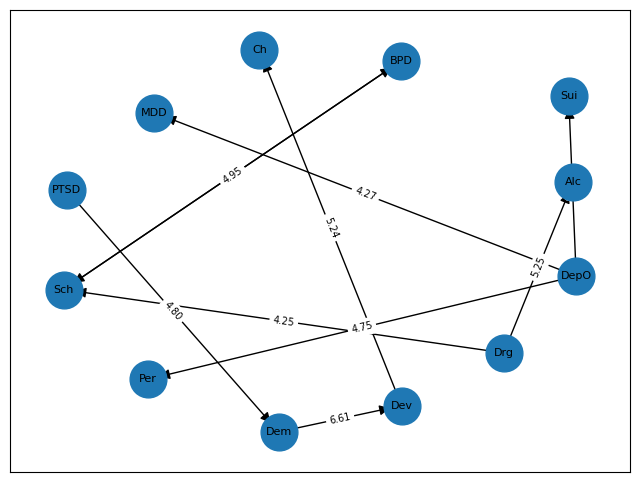

In [19]:
# mental subgraph for drawing
H = G.subgraph(mental_nodes).copy()
print("nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

def edge_weight(edge_tuple):
    return edge_tuple[2].get("weight")

def make_short_labels(G_sub, label_map):
    labels = {}
    for nodeId in G_sub.nodes():
        labels[nodeId] = label_map.get(nodeId, str(nodeId))
    return labels

# top 10 weighted edges in mental graph
edges_sorted = sorted(H.edges(data=True), key=edge_weight, reverse=True)
top_edges = edges_sorted[:10]

H2 = nx.DiGraph()
H2.add_edges_from(top_edges)
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(H2, seed=1, k=6.0)

nx.draw_networkx_nodes(H2, pos, node_size=700)
nx.draw_networkx_edges(H2, pos, arrows=True, arrowstyle='-|>', arrowsize=15, width=1)

labels_short = make_short_labels(H2, label_map)
nx.draw_networkx_labels(H2, pos, labels=labels_short, font_size=8)
edge_labels = {(u, v): f"{d.get('weight', 0):.2f}" for u, v, d in H2.edges(data=True)}
nx.draw_networkx_edge_labels(H2, pos, edge_labels=edge_labels, font_size=7)

plt.show()


Kao primer za interpretaciju kreirane mreža kormobiditeta, odabran je podgraf psihičkih obolenja sa 10 najznačajnijih ivica. Na ovom grafu vidimo da ako je prisutan PTSD (postraumatski šok) odds(izgledi) da se pojavi Dem (demencija) su 4.8 puta (380%) u odnosu kad PTSD nije prisutan.

In [20]:
#  physical subgraph

physical_set = set(physical_cols)
physical_nodes = []
for n in G.nodes():
    if str(n) in physical_set:
        physical_nodes.append(n)

G_p = G.subgraph(physical_nodes).copy()
print("nodes physical:", G_p.number_of_nodes(), "edges:", G_p.number_of_edges())

nodes physical: 78 edges: 928


REZULTAT: Celokupni graf sadrži 95 čvorova i 1327 ivica. Podgraf psihičkih bolesti ima 17 čvorova i 100 ivica, dok podgraf somatskih bolesti ima 78 čvorova i 928 ivica.

***MERE CENTRALNOSTI***

Pre klasterovanja je sprovedena analiza mera centralnosti na psihijatrijskom podgrafu (G_m) da bi se identifikovale dijagnoze sa ključnim pozicijama i ulogama unutar psihijatrijske mreže komorbiditeta. Analiza je sprovedena na nivou podgrafa jer broj čvorova omogućava bolju interpretaciju rezultata. Korišćene mere centralnosti su in-strength, out-strength,closeness i betweenness.

In strength se dobija sumiranjem jačine ulaznih veza, a out strength se dobija sumiranjem izlaznih veza. In strength pokazuje u kojoj meri se druge dijagnoze asociraju sa datom dijagnozom i čvorovi sa visokom vrednošću in-strength su označeni kao ciljne dijagnoze (target). S druge strane, out strength pokazuje u kojoj meri data dijagnoza se asocira sa drugim dijagnozama i čvorovi sa visokom vrednošću out-strength su označeni kao prediktori.

Betweenness nam prikazuje potencijalnu ulogu dijagnoze kao mosta ili posrednika između drugih dijagnoza u mreži, a closeness meri koliko brzo data dijagnoza može dostići ostale u mreži.



ZAŠTO RECIPROČNA VREDNOST?

Budući da se obe mere zasnivaju na najkraćim putevima, distanca je transformisana da bude recipročna vrednost OR-a: distanca= 1/log(OR+ε) Bez transformacije bi veći OR značio kod betweeness i closeness veća distanca (putanja), a to je obrnuto jer ovde je jača veza ako je OR veći.

In [21]:
# distance for the shortest path measures
eps = 1e-12
for u, v, d in G.edges(data=True):
    w = d.get("weight", 1.0)
    d["distance"] = 1.0 / (math.log1p(w) + eps)

In [22]:
# function for centralities
def centralities_for_graph(G0):
    out_strength = dict(G0.out_degree(weight="weight"))
    in_strength = dict(G0.in_degree(weight="weight"))
    in_close = nx.closeness_centrality(G0, distance="distance")
    out_close = nx.closeness_centrality(G0.reverse(), distance="distance")
    betw = nx.betweenness_centrality(G0, weight="distance", normalized=True)
    return out_strength, in_strength, in_close, out_close, betw

In [23]:
# dataframe from centralities
def centralities_df(G0, graph_name):
   out_strength, in_strength, in_close, out_close, betw = centralities_for_graph(G0)

   df = pd.DataFrame({
        "out_strength": pd.Series(out_strength),
        "in_strength": pd.Series(in_strength),
        "in_close": pd.Series(in_close),
        "out_close": pd.Series(out_close),
        "betw": pd.Series(betw),
    })
   df = df.reset_index().rename(columns={"index": "node"})
   return df

In [24]:
# density
def densityFunction(G):
    return nx.density(G)
print("Density of the diseases graph: ", densityFunction(G))
print("Density of the physiological disease graph: ", densityFunction(G_p))
print("Density of the psychological disease graph: ", densityFunction(G_m))

Density of the diseases graph:  0.14860022396416572
Density of the physiological disease graph:  0.15451215451215453
Density of the psychological disease graph:  0.36764705882352944


REZULTAT: Gustina celoukupnog grafa je slična gustini podgrafa somatskih bolesti (približno 0.15) , dok je gustina podgrafa psihičkih bolesti značajno veća (0.37). Budući da graf psihičkih bolesti sadrži manji broj čvorova, a ima značajan broj ivica, ovakav rezultat se

In [25]:
# dataframes for graphs
df_m = centralities_df(G_m, "mental")

In [26]:
# top k
def topk(df, metric, k=3):
    return (
        df.sort_values(metric, ascending=False)
          .loc[:, ["node", metric]]
          .head(k)
    )

print("How well-positioned a psychiatric diagnosis is to be reached by other psychiatric diagnosis: ")
print(topk(df_m, "in_close"))
print(" ")
print("How well-positioned a psychiatric diagnosis is is to reach other psychiatric diagnosis:")
print(topk(df_m, "out_close"))
print(" ")
print("How centrally a a psychiatric diagnosis lies on important paths between other psychiatric diagnosis: ")
print(topk(df_m, "betw"))


How well-positioned a psychiatric diagnosis is to be reached by other psychiatric diagnosis: 
                            node  in_close
11         AHRQ_PersonalityDO_DT  0.695652
16  AHRQ_SuicideAndSelfInjury_DT  0.666667
9                  NEPEC_SCHZ_DT  0.640000
 
How well-positioned a psychiatric diagnosis is is to reach other psychiatric diagnosis:
                        node  out_close
12           NEPEC_DXODep_DT   1.000000
13  AHRQ_DementiaAndOthDO_DT   0.800000
4              NEPEC_PTSD_DT   0.761905
 
How centrally a a psychiatric diagnosis lies on important paths between other psychiatric diagnosis: 
                            node      betw
12               NEPEC_DXODep_DT  0.261272
14                NEPEC_DXDRG_DT  0.210353
16  AHRQ_SuicideAndSelfInjury_DT  0.112158


In [27]:
# node roles
def add_strength_role(df, in_col="in_strength", out_col="out_strength", q=0.75):
    df = df.copy()
    in_thr = df[in_col].quantile(q)
    out_thr = df[out_col].quantile(q)

    def strength_role(row):
        high_in = row[in_col] >= in_thr
        high_out = row[out_col] >= out_thr

        if high_in and high_out:
            return "hub"
        elif high_out and not high_in:
            return "predictor"
        elif high_in and not high_out:
            return "target"
        else:
            return "other"

    df["role"] = df.apply(strength_role, axis=1)
    return df



In [28]:
df_m_roles = add_strength_role(df_m)

df_m_roles["strength_balance"] = (
    (df_m_roles["out_strength"] - df_m_roles["in_strength"])/(df_m_roles["out_strength"] + df_m_roles["in_strength"] + 1e-9)
)
#print( df_m_roles.columns)


In [29]:
top_predictors = (
    df_m_roles[df_m_roles["role"] == "predictor"][["node", "in_strength", "out_strength", "role", "strength_balance"]]
    .sort_values("out_strength", ascending=False)
    .reset_index(drop=True)
)
top_predictors.index += 1

print("Predictors:")
print(top_predictors)

Predictors:
                       node  in_strength  out_strength       role  \
1           NEPEC_DXODep_DT    10.134034     49.145493  predictor   
2  AHRQ_DementiaAndOthDO_DT    10.558107     31.692761  predictor   
3             NEPEC_PTSD_DT     8.201442     27.939517  predictor   
4            NEPEC_DXDRG_DT    21.659593     25.502704  predictor   

   strength_balance  
1          0.658093  
2          0.500218  
3          0.546141  
4          0.081487  


In [30]:
top_hubs = (
    df_m_roles[df_m_roles["role"] == "hub"][["node", "in_strength", "out_strength", "role","strength_balance"]]
    .reset_index(drop=True)
)
top_predictors.index += 1

print("Hubs:")
print(top_hubs)

Hubs:
              node  in_strength  out_strength role  strength_balance
0  NEPEC_AFBPDX_DT    22.668503     23.458959  hub          0.017136


In [31]:
top_targets = (
    df_m_roles[df_m_roles["role"] == "target"][["node", "in_strength", "out_strength", "role","strength_balance"]]
    .sort_values("in_strength", ascending=False)
    .reset_index(drop=True)
)
top_targets.index += 1

print("Targets:")
print(top_targets)

Targets:
                           node  in_strength  out_strength    role  \
1  AHRQ_SuicideAndSelfInjury_DT    27.750829     15.735176  target   
2         AHRQ_PersonalityDO_DT    27.434480     19.398785  target   
3                 NEPEC_SCHZ_DT    26.552942     21.890029  target   
4       AHRQ_DevelopmentalDO_DT    21.719833     14.100193  target   

   strength_balance  
1         -0.276311  
2         -0.171581  
3         -0.096256  
4         -0.212720  


Vizuelni prikaz na osnovu in_strength i out_strength kod grafa psihičkih bolesti

In [32]:
def draw_top_edges_by_metric(
    H,
    df_metrics,
    label_map,
    metric_col="in_strength",   #default da bude
    top_n_edges=100,
    base_size=200,
    size_scale=40,
    layout="kamada_kawai",
    layout_seed=1,
    layout_k=6.0,
    layout_scale=3.0,
    cmap=plt.cm.Blues,
    figsize=(9, 7),
):
    def edge_weight(edge_tuple):
        return edge_tuple[2].get("weight", 0)

    def make_short_labels(G_sub, label_map):
        return {nodeId: label_map.get(nodeId, str(nodeId)) for nodeId in G_sub.nodes()}

    edges_sorted = sorted(H.edges(data=True), key=edge_weight, reverse=True)
    top_edges = edges_sorted[:top_n_edges]

    H2 = nx.DiGraph()
    H2.add_edges_from(top_edges)

    metric_dict = df_metrics.set_index("node")[metric_col].to_dict()
    node_values = [metric_dict.get(n, 0) for n in H2.nodes()]
    node_sizes = [base_size + size_scale * metric_dict.get(n, 0) for n in H2.nodes()]

    labels_short = make_short_labels(H2, label_map)

    plt.figure(figsize=figsize)

    if layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(H2)
        pos = {n: (xy[0] * layout_scale, xy[1] * layout_scale) for n, xy in pos.items()}
    else:
        pos = nx.spring_layout(H2, seed=layout_seed, k=layout_k)

    nx.draw_networkx_nodes(
        H2, pos,
        node_size=node_sizes,
        node_color=node_values,
        cmap=cmap,
        edgecolors="black",
        linewidths=0.5
    )

    nx.draw_networkx_edges(
        H2, pos,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=12,
        width=0.8,
        alpha=0.35,
        edge_color="gray",
        min_source_margin=2,
        min_target_margin=2
    )

    nx.draw_networkx_labels(
        H2, pos,
        labels=labels_short,
        font_size=8
    )

    plt.axis("off")
    plt.show()

GRAF NA OSNOVU IN STRENGTH PSIHIČKIH DIJAGNOZA PODGRAFA:

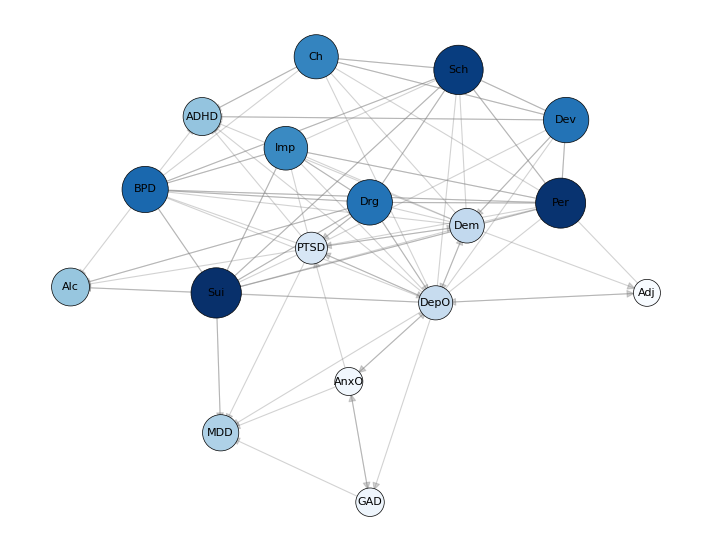

In [33]:
draw_top_edges_by_metric(
    H=H,
    df_metrics=df_m,
    label_map=label_map,
    metric_col="in_strength",
)

Interpretacija rezultata:

Prema apsolutnoj vrednosti in-strength izdvajaju se sledeće dijagnoze kao potencijalne ciljne dijagnoze: suicidalno ponašanje,poremećaj ličnosti, šizofreni poremećaj i razvojni poremećaj.

GRAF NA OSNOVU OUT STRENGTH PSIHIČKIH DIJAGNOZA PODGRAFA:

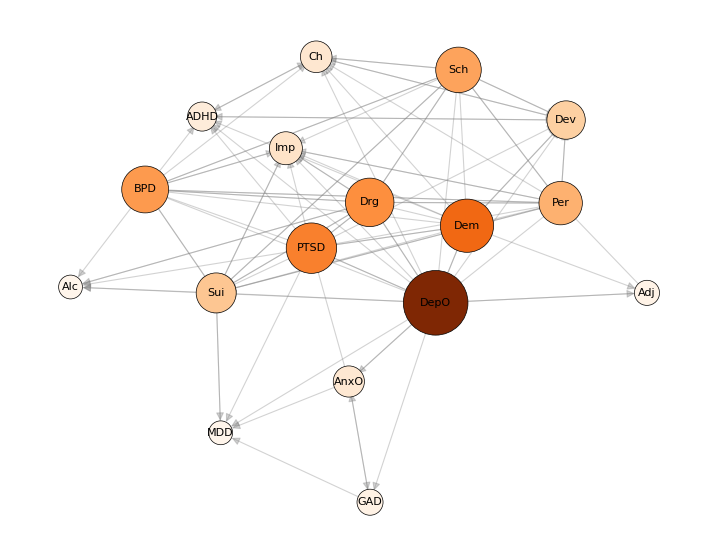

In [34]:
draw_top_edges_by_metric(
    H=H,
    df_metrics=df_m,
    label_map=label_map,
    metric_col="out_strength",
    cmap=plt.cm.Oranges,
)

GRAF NA OSNOVU BETWEENESS PSIHIČKIH DIJAGNOZA PODGRAFA:

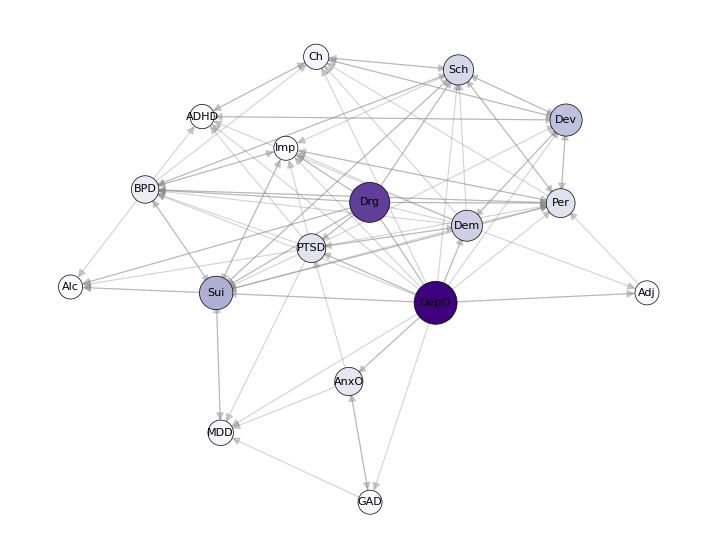

In [35]:
draw_top_edges_by_metric(
    H=H,
    df_metrics=df_m,
    label_map=label_map,
    metric_col="betw",
    base_size=300,
    size_scale=2500,
    cmap=plt.cm.Purples,
)

Interpretacija rezultata:

Posmatrajući apsolutnu vrednost out-strength-a i balans između in i out strength-a, Minor depression, dementia i PTSD se ističu u ulozi prediktora.

In [36]:
# cross-edge counts
def count_cross_edges_in_graph(G, mental_set, physical_set):
    m2p = 0
    p2m = 0
    m2m = 0
    p2p = 0
    other = 0

    for u, v in G.edges():
        u_is_m = str(u) in mental_set
        v_is_m = str(v) in mental_set
        u_is_p = str(u) in physical_set
        v_is_p = str(v) in physical_set

        if u_is_m and v_is_p:
            m2p += 1
        elif u_is_p and v_is_m:
            p2m += 1
        elif u_is_m and v_is_m:
            m2m += 1
        elif u_is_p and v_is_p:
            p2p += 1
        else:
            other += 1

    return {
        "mental→physical": m2p,
        "physical→mental": p2m,
        "mental→mental": m2m,
        "physical→physical": p2p,
        "total_edges": G.number_of_edges()
    }

counts = count_cross_edges_in_graph(G, mental_set, physical_set)
print(counts)

{'mental→physical': 227, 'physical→mental': 72, 'mental→mental': 100, 'physical→physical': 928, 'total_edges': 1327}


In [37]:
# top mental to physical outgoing edges
def top_cross_out_degree(G, mental_set, physical_set, topk=10):
    cnt = Counter()
    for u, v in G.edges():
        if str(u) in mental_set and str(v) in physical_set:
            cnt[u] += 1
    return cnt.most_common(topk)

print(top_cross_out_degree(G, mental_set, physical_set, topk=10))

[('NEPEC_DXODep_DT', 75), ('AHRQ_DementiaAndOthDO_DT', 48), ('NEPEC_SCHZ_DT', 29), ('NEPEC_DXDRG_DT', 26), ('NEPEC_PTSD_DT', 15), ('AHRQ_DevelopmentalDO_DT', 14), ('AHRQ_PersonalityDO_DT', 9), ('NEPEC_AFBPDX_DT', 5), ('AHRQ_SuicideAndSelfInjury_DT', 3), ('NEPEC_DXALC_DT', 2)]


In [38]:
!pip -q install igraph leidenalg scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.0 MB/s eta 0:00:00


KLASTEROVANJE KORISCENJEM LOUVAIN ALGORITMA

In [39]:
def to_undirected_projection_mean(G):
  #napravi neusmeren graf i doda cvorove usmerenog
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    loadedEdges=set()#SKUP UCITANIH IVICA
    for u,v in G.edges():
        a,b=sorted([u,v])#da uvek gleda jedan kao u drugi kao v i uv il vu je nebitno
        if (a,b) in loadedEdges:
            continue
        loadedEdges.add((a, b))
        w_uv = float(G[u][v].get("weight", 0.0)) if G.has_edge(u,v) else 0.0
        w_vu = float(G[v][u].get("weight", 0.0)) if G.has_edge(v,u) else 0.0
        w = (w_uv + w_vu) / 2.0
        if w > 0:
            H.add_edge(a, b, weight=w)
    return H

In [115]:
H_m= to_undirected_projection_mean(G_m)# mental undirected subgraph
H_p= to_undirected_projection_mean(G_p)# physical diseases undirected subgraph

In [116]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import normalized_mutual_info_score
#POMOCNE FJE

def comms_to_map(comms):
    """
    list[set] -> dict node -> community_id
    """
    comm_map = {}
    for cid, nodeset in enumerate(comms):
        for n in nodeset:
            comm_map[n] = cid#dodeljulje dict cvor:klaster kojem pripada id
    return comm_map

def comm_map_to_labels(comm_map, nodes_order): ##JJ: nisam razumela sta ova f. radi i cemu sluzi
    """
    dict node->cid -> lista labela po fiksnom redosledu čvorova za nmi
    """
    return [comm_map[n] for n in nodes_order] #za dict cvor:klaster kojem pripada id

In [117]:
def build_consensus_matrix(labels_list):
    n = len(labels_list[0])
    C = np.zeros((n, n), dtype=float)
    for labels in labels_list:
        labels = np.array(labels)
        C += (labels[:, None] == labels[None, :]).astype(float)
    return C / len(labels_list)

def consensus_matrix_to_graph(C, nodes_order, threshold=0.5):
    G = nx.Graph()
    G.add_nodes_from(nodes_order)
    n = len(nodes_order)
    rows, cols = np.triu_indices(n, k=1)
    mask = C[rows, cols] >= threshold
    for i, j in zip(rows[mask], cols[mask]):
        G.add_edge(nodes_order[i], nodes_order[j], weight=float(C[i, j]))
    return G

In [141]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations
import matplotlib.pyplot as plt

def consensus_partition_for_resolution(H, res, seeds, weight="weight",
                                        consensus_threshold=0.5):
    nodes_order = list(H.nodes())
    labels_list, rows = [], []
    for seed in seeds:
        comms    = louvain_communities(H, weight=weight, resolution=res, seed=seed)
        comm_map = comms_to_map(comms)
        labels   = comm_map_to_labels(comm_map, nodes_order)
        labels_list.append(labels)
        Q = modularity(H, comms, weight=weight, resolution=res)
        rows.append({"resolution": res, "seed": seed,
                     "n_communities": len(comms), "modularity": float(Q)})
    df_runs = pd.DataFrame(rows)
    C  = build_consensus_matrix(labels_list)
    Gc = consensus_matrix_to_graph(C, nodes_order, threshold=consensus_threshold)
    consensus_comms  = louvain_communities(Gc, weight="weight", resolution=1.0, seed=0)
    consensus_map    = comms_to_map(consensus_comms)
    consensus_labels = comm_map_to_labels(consensus_map, nodes_order)
    consensus_Q      = modularity(H, consensus_comms, weight=weight, resolution=res)
    nmi_scores = [normalized_mutual_info_score(la, lb, average_method="arithmetic")
                  for la, lb in combinations(labels_list, 2)]
    return {
        "df_runs": df_runs, "nodes_order": nodes_order,
        "labels_list": labels_list, "consensus_matrix": C,
        "consensus_graph": Gc, "consensus_comms": consensus_comms,
        "consensus_labels": consensus_labels, "consensus_k": len(consensus_comms),
        "consensus_modularity": float(consensus_Q),
        "mean_nmi_between_runs": float(np.mean(nmi_scores)),
    }

def louvain_consensus_sweep(H, resolutions, seeds, weight="weight",
                             consensus_threshold=0.5):
    results, summary_rows = {}, []
    for res in resolutions:
        out     = consensus_partition_for_resolution(H, res, seeds, weight,
                                                     consensus_threshold)
        df_runs = out["df_runs"]
        k_mode  = int(df_runs["n_communities"].mode().iloc[0])
        summary_rows.append({
            "resolution": res, "runs": len(df_runs), "k_mode": k_mode,
            "k_mode_freq": int((df_runs["n_communities"] == k_mode).sum()),
            "k_min": int(df_runs["n_communities"].min()),
            "k_max": int(df_runs["n_communities"].max()),
            "modularity_mean": float(df_runs["modularity"].mean()),
            "modularity_std":  float(df_runs["modularity"].std(ddof=0)),
            "consensus_k":     int(out["consensus_k"]),
            "consensus_modularity": float(out["consensus_modularity"]),
            "mean_nmi": out["mean_nmi_between_runs"],
        })
        results[res] = out
    return results, (pd.DataFrame(summary_rows)
                     .sort_values("resolution").reset_index(drop=True))


In [142]:
def write_communities(comms, naziv=""):
    if naziv:
        print(f"\n{'='*50}\n{naziv}\n{'='*50}")
    for cid, c in enumerate(comms):
        print(f"Zajednica {cid} (n={len(c)}):")
        print(sorted(c))
        print("-" * 40)

def diagnostic_plotting(cons_summary, chosen_res, naziv=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    if naziv:
        fig.suptitle(naziv, fontsize=12)
    ax1.plot(cons_summary["resolution"], cons_summary["consensus_k"],
             color="#185FA5", linewidth=1.8)
    ax1.axvline(chosen_res, color="orange", linestyle="--", label=f"γ={chosen_res}")
    ax1.set(xlabel="γ", ylabel="k", title="k vs γ")
    ax1.legend(); ax1.grid(alpha=0.2)
    ax2.plot(cons_summary["resolution"], cons_summary["mean_nmi"],
             color="#D85A30", linewidth=1.8)
    ax2.axvline(chosen_res, color="orange", linestyle="--", label=f"γ={chosen_res}")
    ax2.set(xlabel="γ", ylabel="NMI", title="Stabilnost vs γ", ylim=(0.5, 1.02))
    ax2.legend(); ax2.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

In [217]:
def analiziraj_mrezu(cons_results, cons_summary, chosen_res,
                     G, label_map, naziv="", threshold_quantile=0.5):
    key   = min(cons_results.keys(), key=lambda x: abs(x - chosen_res))
    out   = cons_results[key]
    comms = out["consensus_comms"]

    diagnostic_plotting(cons_summary, chosen_res, naziv)
    write_communities(comms, naziv)

    plot_louvain_graph(G, comms, naziv, label_map,
                       threshold_quantile=threshold_quantile)

    return comms

In [218]:
def plot_graph_communities(
    G,
    title,
    node_labels=None,
    node_color_modifiers=None,
    node_size_modifiers=None,
    edge_weight_multiplier=1.0,
    layout_seed=30,
    threshold_quantile=None,
    use_mst_top=False,
    top_pct=0.02
):
    if use_mst_top:
        G_plot = build_mst_plus_top_edges(G, top_pct=top_pct)

    elif threshold_quantile is not None:
        weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
        threshold = np.quantile(weights, threshold_quantile)

        G_plot = nx.Graph()
        G_plot.add_nodes_from(G.nodes())
        G_plot.add_edges_from(
            (u, v, d) for u, v, d in G.edges(data=True)
            if d["weight"] >= threshold
        )
    else:
        G_plot = G.copy()

    pos = nx.spring_layout(G_plot, seed=layout_seed, k=2.0)

    nodes = list(G_plot.nodes())

    if node_color_modifiers is None:
        node_colors = "lightblue"
    else:
        node_colors = [node_color_modifiers.get(n, -1) for n in nodes]

    if node_size_modifiers is None:
        node_sizes = 500
    else:
        vals = np.array([node_size_modifiers.get(n, 0) for n in nodes], dtype=float)
        vmin, vmax = vals.min(), vals.max()
        node_sizes = 400 + 1800 * (vals - vmin) / (vmax - vmin + 1e-9)

    edges = list(G_plot.edges())
    if edges:
        ew = np.array([G_plot[u][v].get("weight", 1.0) for u, v in edges], dtype=float)
        ew_min, ew_max = ew.min(), ew.max()

        edge_width_min = 0.2
        edge_width_max = 1.2
        edge_widths = edge_weight_multiplier * (
            edge_width_min +
            (edge_width_max - edge_width_min) * (ew - ew_min) / (ew_max - ew_min + 1e-9)
        )
    else:
        edge_widths = []

    if node_labels is None:
        labels = {n: n for n in nodes}
    else:
        labels = {n: node_labels.get(n, n) for n in nodes}

    plt.figure(figsize=(16, 12))

    nx.draw_networkx_nodes(
        G_plot, pos,
        nodelist=nodes,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.95,
        edgecolors="black",
        linewidths=0.4
    )

    nx.draw_networkx_edges(
        G_plot, pos,
        edgelist=edges,
        width=edge_widths,
        alpha=0.28,
        edge_color="gray"
    )

    nx.draw_networkx_labels(
        G_plot, pos,
        labels=labels,
        font_size=9
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

In [219]:
def plot_louvain_graph(G, comms, title, label_map, edge_weight_multiplier=2.0, threshold_quantile=0.5):
    # node -> community id
    partition = {}
    for i, community in enumerate(comms):
        for node in community:
            partition[node] = i

    # short labels
    labels_dict = {node: label_map.get(node, node) for node in G.nodes()}

    # node size summed weighted degree
    node_strength = dict(G.degree(weight="weight"))

    plot_graph_communities(
        G,
        title,
        node_labels=labels_dict,
        node_color_modifiers=partition,
        node_size_modifiers=node_strength,
        edge_weight_multiplier=edge_weight_multiplier,
        threshold_quantile=threshold_quantile
    )

In [147]:
# sweep pokretanje mentalne
resolutions = np.arange(0, 4.01, 0.01)
seeds = range(20)
cons_results, cons_summary = louvain_consensus_sweep( H=H_m,
    resolutions=resolutions,
    seeds=seeds,
    weight="weight",
    consensus_threshold=0.5)



In [186]:
# sweep fizičke ima ih više pa manji broj optimizacija
resolutions_p = np.arange(0, 4.01, 0.01)
cons_results_p, cons_summary_p = louvain_consensus_sweep(
    H=G_p, resolutions=resolutions_p, seeds=range(20))


In [187]:
print(cons_summary_p[["resolution", "consensus_k", "mean_nmi"]]
      .to_string())#za fizičke bolesti

     resolution  consensus_k  mean_nmi
0          0.00            1  1.000000
1          0.01            1  1.000000
2          0.02            1  1.000000
3          0.03            1  1.000000
4          0.04            1  1.000000
5          0.05            1  1.000000
6          0.06            1  1.000000
7          0.07            1  1.000000
8          0.08            1  1.000000
9          0.09            1  1.000000
10         0.10            1  1.000000
11         0.11            1  1.000000
12         0.12            1  1.000000
13         0.13            1  1.000000
14         0.14            1  1.000000
15         0.15            1  1.000000
16         0.16            1  1.000000
17         0.17            1  1.000000
18         0.18            1  1.000000
19         0.19            1  1.000000
20         0.20            1  1.000000
21         0.21            1  1.000000
22         0.22            1  1.000000
23         0.23            1  1.000000
24         0.24          

In [150]:
print(cons_summary[["resolution", "consensus_k", "mean_nmi"]]
      .to_string())#za ment bolesti

     resolution  consensus_k  mean_nmi
0          0.00            1  1.000000
1          0.01            1  1.000000
2          0.02            1  1.000000
3          0.03            1  1.000000
4          0.04            1  1.000000
5          0.05            1  1.000000
6          0.06            1  1.000000
7          0.07            1  1.000000
8          0.08            1  1.000000
9          0.09            1  1.000000
10         0.10            1  1.000000
11         0.11            1  1.000000
12         0.12            1  1.000000
13         0.13            1  1.000000
14         0.14            1  1.000000
15         0.15            1  1.000000
16         0.16            1  1.000000
17         0.17            1  1.000000
18         0.18            1  1.000000
19         0.19            1  1.000000
20         0.20            1  1.000000
21         0.21            1  1.000000
22         0.22            1  1.000000
23         0.23            1  1.000000
24         0.24          

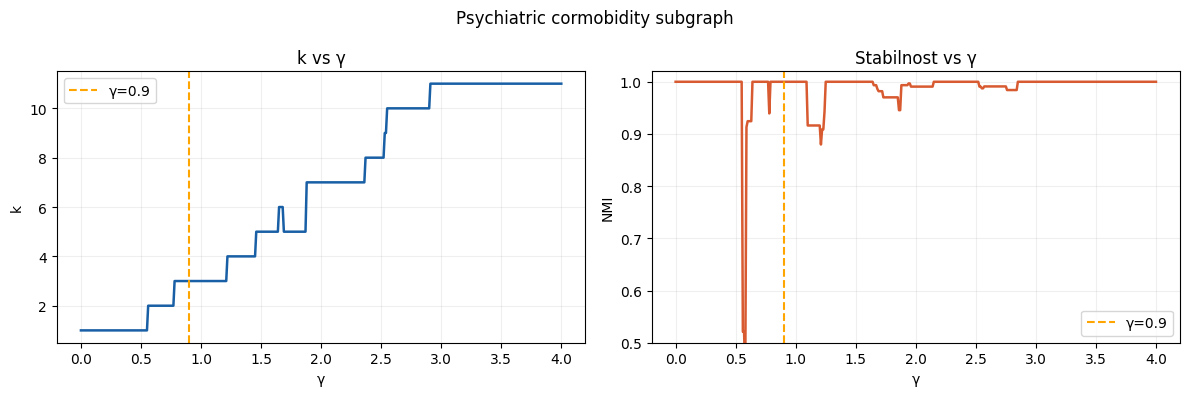


Psychiatric cormobidity subgraph
Zajednica 0 (n=6):
['AHRQ_AdjustmentDO_DT', 'NEPEC_ANXgen_DT', 'NEPEC_ANXunsp_DT', 'NEPEC_DXODep_DT', 'NEPEC_MDD_DT', 'NEPEC_PTSD_DT']
----------------------------------------
Zajednica 1 (n=7):
['AHRQ_ImpulseControlDONEC_DT', 'AHRQ_PersonalityDO_DT', 'AHRQ_SuicideAndSelfInjury_DT', 'NEPEC_AFBPDX_DT', 'NEPEC_DXALC_DT', 'NEPEC_DXDRG_DT', 'NEPEC_SCHZ_DT']
----------------------------------------
Zajednica 2 (n=4):
['AHRQ_AttentionDeficitDO_DT', 'AHRQ_DOInChildhood_DT', 'AHRQ_DementiaAndOthDO_DT', 'AHRQ_DevelopmentalDO_DT']
----------------------------------------


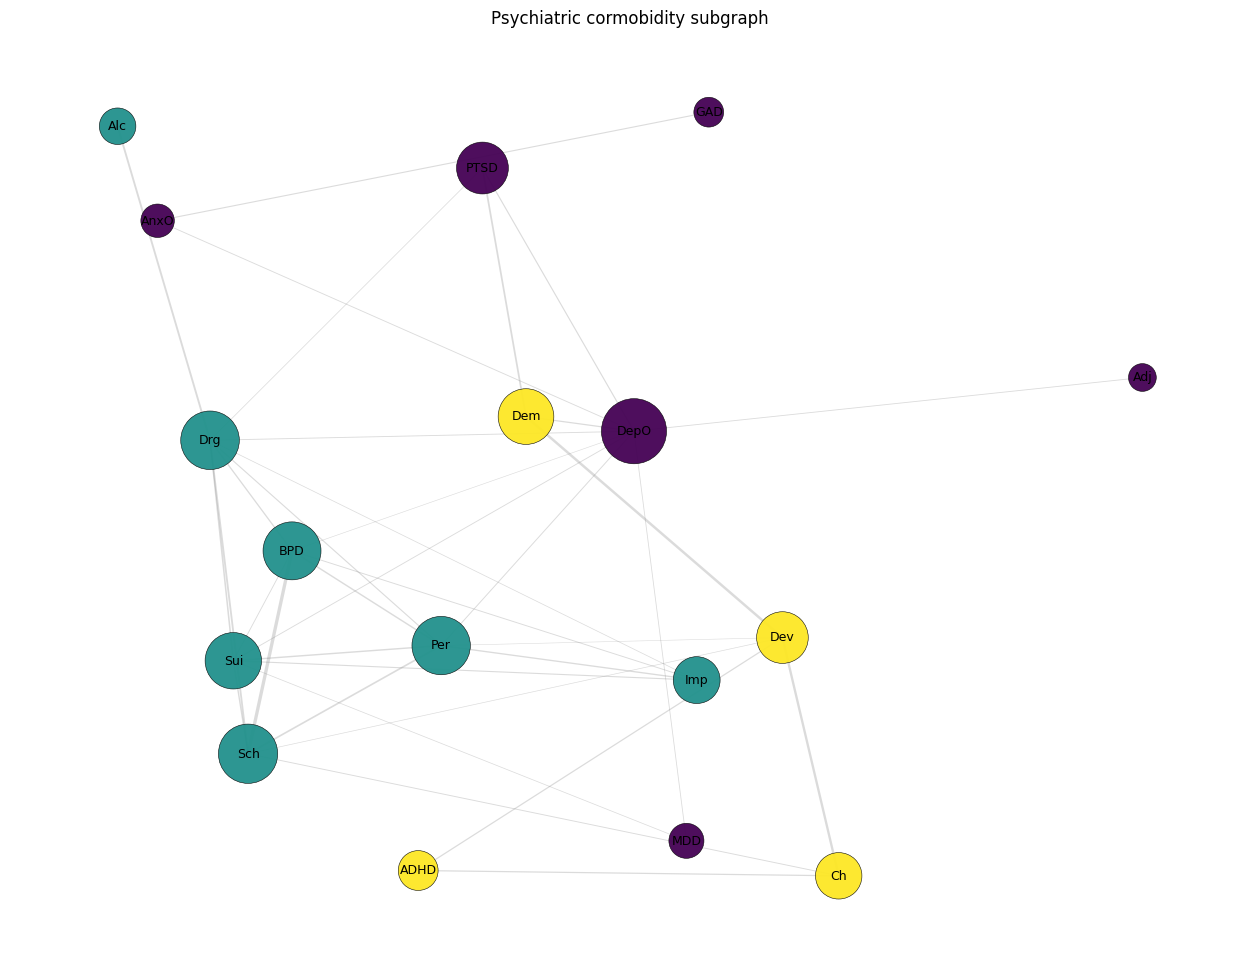

In [220]:

# pozivi
comms_m = analiziraj_mrezu(cons_results, cons_summary, 0.9,
                            H_m, label_map, "Psychiatric cormobidity subgraph",
                            threshold_quantile=0.5)


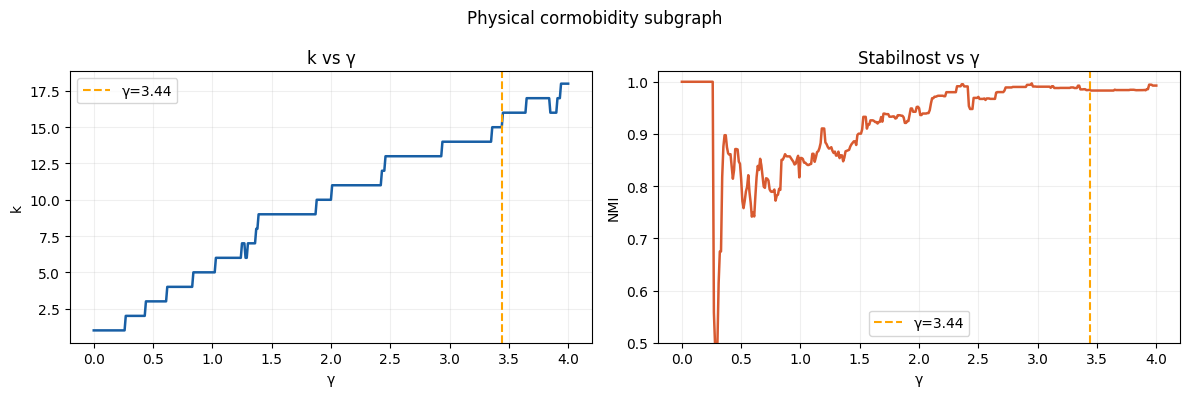


Physical cormobidity subgraph
Zajednica 0 (n=9):
['AHRQ_AbdominalHernia_DT', 'AHRQ_DisOfVeins_DT', 'AHRQ_GIHemorrhage_DT', 'AHRQ_IntestinalInfection_DT', 'AHRQ_LowerGIDO_DT', 'AHRQ_NoninfectiousGastroenterit0', 'AHRQ_OthGIDO_DT', 'AHRQ_UpperGIDO_DT', 'cancerdxDT']
----------------------------------------
Zajednica 1 (n=5):
['AHRQ_Anemia_DT', 'AHRQ_CoagulationDO_DT', 'AHRQ_DisOfWhiteBloodCells_DT', 'AHRQ_FluidAndElectrolyteDO_DT', 'AHRQ_OthHematologicConditions_DT']
----------------------------------------
Zajednica 2 (n=3):
['AHRQ_BacterialInfection_DT', 'AHRQ_ChronicUlcerOfSkin_DT', 'AHRQ_InfectiveArthritis_DT']
----------------------------------------
Zajednica 3 (n=9):
['AHRQ_BiliaryTractDs_DT', 'AHRQ_DOOfLipidMetabolism_DT', 'AHRQ_GoutAndOth_DT', 'AHRQ_Hypertension_DT', 'AHRQ_LiverDs_DT', 'AHRQ_NutritionalDeficiencies_DT', 'AHRQ_OthNutritionalEndocrineDO_D', 'AHRQ_PancreaticDO_DT', 'dmdxDT']
----------------------------------------
Zajednica 4 (n=5):
['AHRQ_Burns_DT', 'AHRQ_Crushi

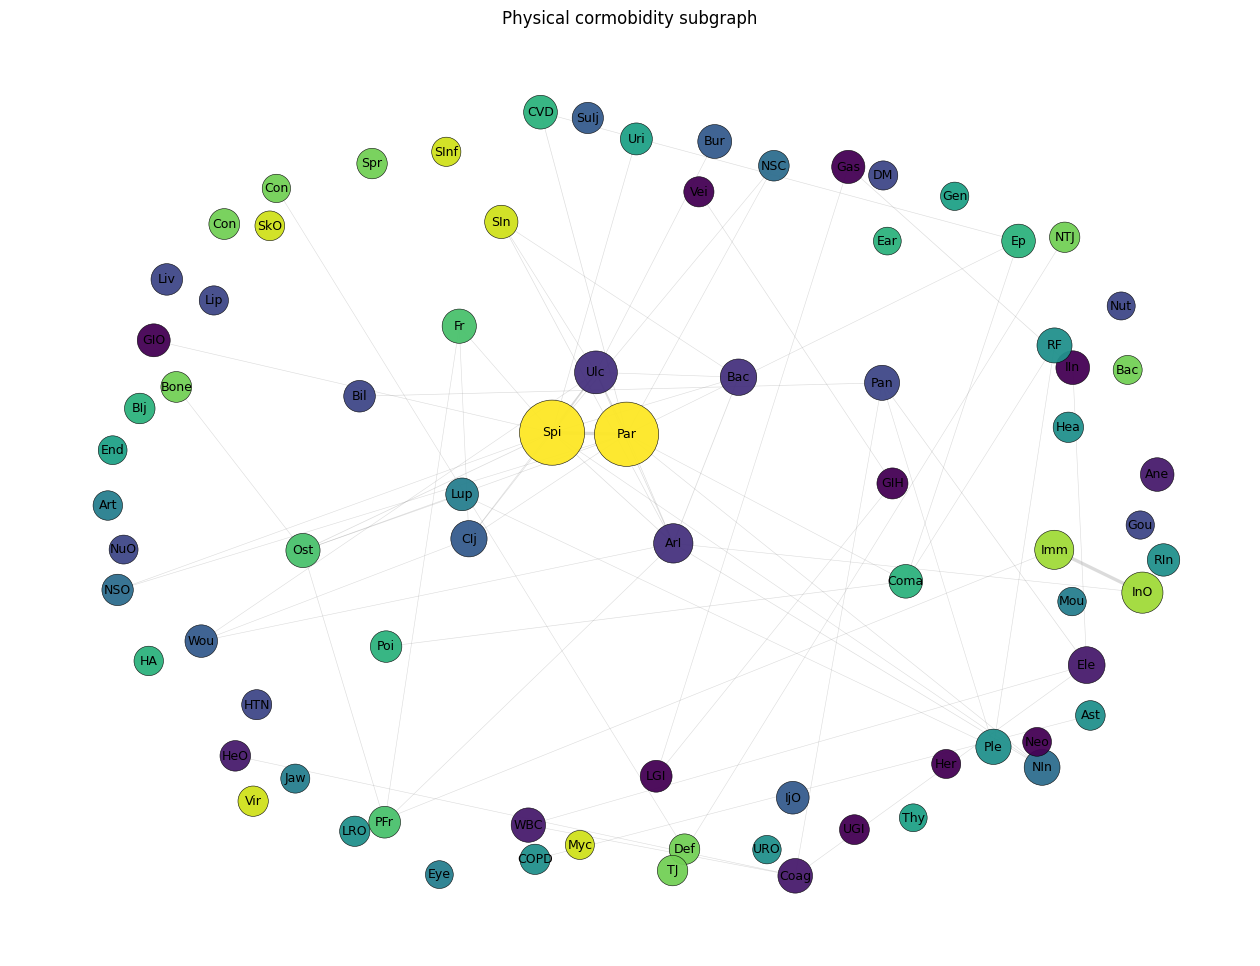

In [221]:

comms_p = analiziraj_mrezu(cons_results_p, cons_summary_p, 3.44,
                            G_p, label_map, "Physical cormobidity subgraph",
                            threshold_quantile=0.9)